# PINN — 1D Reaction Equation

$$\frac{\partial u}{\partial t} - \rho u(1-u) = 0, \quad x \in [0, 2\pi],\ t \in [0,1]$$

**IC:** $u(x,0) = h(x) = \exp\!\left(-\dfrac{(x-\pi)^2}{2(\pi/4)^2}\right)$

**BC:** $u(0,t) = u(2\pi, t)$ (periodic)

**Exact solution:**
$$u_{\text{analytical}} = \frac{h(x)\exp(\rho t)}{h(x)\exp(\rho t) + 1 - h(x)}, \quad \rho = 5$$

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinns import PINN

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Problem Setup

In [20]:
RHO  = 5.0
X_L  = 0.0
X_R  = 2 * np.pi

def h(x):
    """Initial condition (Gaussian)."""
    return np.exp(-((x - np.pi) ** 2) / (2 * (np.pi / 4) ** 2))

def h_torch(x):
    return torch.exp(-((x - torch.pi) ** 2) / (2 * (torch.pi / 4) ** 2))

def exact(x, t):
    hx = h(x)
    return hx * np.exp(RHO * t) / (hx * np.exp(RHO * t) + 1 - hx + 1e-10)

# Quick sanity check: IC at t=0 should equal h(x)
x_check = np.linspace(0, 2*np.pi, 200)
assert np.allclose(exact(x_check, 0), h(x_check), atol=1e-6), "IC check failed"
print("Exact solution sanity check passed.")

Exact solution sanity check passed.


## 2. Data Generation

In [21]:
N_pde = 3000
N_ic  = 300
N_bc  = 300   # periodic: x=0 and x=2pi at same t values

# --- PDE collocation: uniform random in [0, 2pi] x [0, 1] ---
x_pde_np = np.random.uniform([X_L, 0.0], [X_R, 1.0], size=(N_pde, 2))
x_pde = torch.tensor(x_pde_np, dtype=torch.float32, device=device)

# --- IC: t = 0 ---
x_ic_np = np.random.uniform(X_L, X_R, size=(N_ic, 1))
t_ic_np = np.zeros((N_ic, 1))
x_ic = torch.tensor(np.hstack([x_ic_np, t_ic_np]), dtype=torch.float32, device=device)
u_ic = torch.tensor(h(x_ic_np), dtype=torch.float32, device=device)

# --- BC: periodic u(0,t) = u(2pi, t)
# Enforce via supervised BC using exact values (both sides equal by symmetry of h)
t_bc_np = np.random.uniform(0.0, 1.0, size=(N_bc, 1))
x_left_np  = np.hstack([np.full((N_bc, 1), X_L), t_bc_np])
x_right_np = np.hstack([np.full((N_bc, 1), X_R), t_bc_np])
u_left_np  = exact(X_L, t_bc_np)
u_right_np = exact(X_R, t_bc_np)

x_bc = torch.tensor(np.vstack([x_left_np, x_right_np]), dtype=torch.float32, device=device)
u_bc = torch.tensor(np.vstack([u_left_np, u_right_np]), dtype=torch.float32, device=device)

print(f"PDE  : {x_pde.shape}")
print(f"IC   : {x_ic.shape}  u_ic: {u_ic.shape}")
print(f"BC   : {x_bc.shape}  u_bc: {u_bc.shape}")

PDE  : torch.Size([3000, 2])
IC   : torch.Size([300, 2])  u_ic: torch.Size([300, 1])
BC   : torch.Size([600, 2])  u_bc: torch.Size([600, 1])


## 3. PDE Residual

In [22]:
def reaction_residual(model, xt):
    """
    PDE: u_t - rho * u * (1 - u) = 0
    xt[:, 0] = x,  xt[:, 1] = t
    """
    u = model(xt)                            # [N, 1]
    u_t = torch.autograd.grad(
        u, xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0][:, 1:2]                             # du/dt

    return u_t - RHO * u * (1.0 - u)

## 4. Model & Training

In [23]:
model = PINN(
    layers=[2, 128, 128, 128, 128, 1],
    activation="tanh",
    residual=False,
    skip=True,
    use_fourier=False,
    use_ntk=False,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 99,585


In [24]:
model.fit(
    pde_fn=reaction_residual,
    x_pde=x_pde,
    x_bc=x_bc,
    u_bc=u_bc,
    x_ic=x_ic,
    u_ic=u_ic,
    epochs=20000,
    lr=1e-4,
    w_pde=1.0,
    w_bc=1.0,
    w_ic=1.0,
    ntk_adaptive=False,
    ntk_update_every=1000,
    log_every=100,
    save_path="./best_reaction.pt",
)

[     1/20000]  Total: 1.646e+00  PDE: 1.405e+00  BC: 1.188e-01  IC: 1.224e-01
[   100/20000]  Total: 2.044e-01  PDE: 8.238e-03  BC: 1.044e-03  IC: 1.951e-01
[   200/20000]  Total: 2.025e-01  PDE: 9.133e-03  BC: 8.274e-04  IC: 1.925e-01
[   300/20000]  Total: 2.011e-01  PDE: 9.833e-03  BC: 6.493e-04  IC: 1.906e-01
[   400/20000]  Total: 2.001e-01  PDE: 1.055e-02  BC: 5.343e-04  IC: 1.890e-01
[   500/20000]  Total: 1.995e-01  PDE: 1.116e-02  BC: 4.502e-04  IC: 1.879e-01
[   600/20000]  Total: 1.990e-01  PDE: 1.165e-02  BC: 3.795e-04  IC: 1.869e-01
[   700/20000]  Total: 1.985e-01  PDE: 1.205e-02  BC: 3.187e-04  IC: 1.861e-01
[   800/20000]  Total: 1.981e-01  PDE: 1.242e-02  BC: 2.675e-04  IC: 1.854e-01
[   900/20000]  Total: 1.977e-01  PDE: 1.279e-02  BC: 2.255e-04  IC: 1.847e-01
[  1000/20000]  Total: 1.973e-01  PDE: 1.316e-02  BC: 1.923e-04  IC: 1.839e-01
[  1100/20000]  Total: 1.968e-01  PDE: 1.358e-02  BC: 1.685e-04  IC: 1.830e-01
[  1200/20000]  Total: 1.962e-01  PDE: 1.412e-02  BC

## 5. Loss History

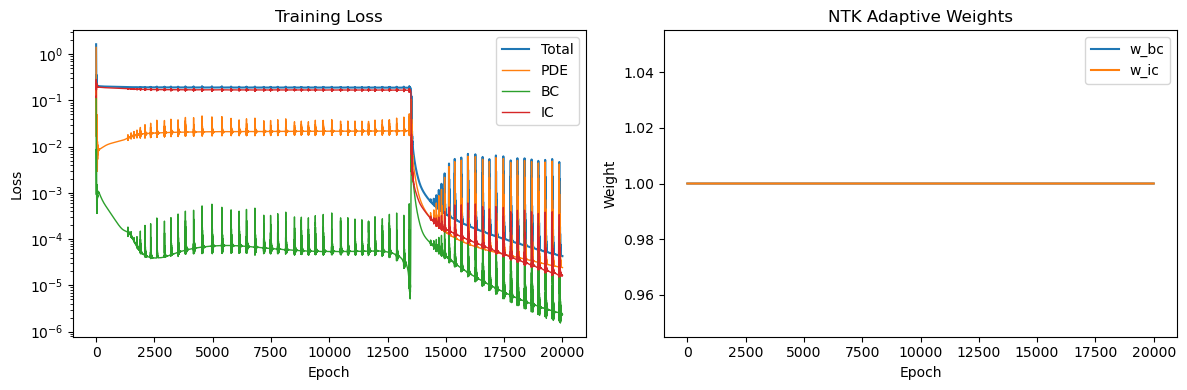

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(model.loss_history["total"], label="Total",  lw=1.5)
ax.semilogy(model.loss_history["pde"],   label="PDE",    lw=1)
ax.semilogy(model.loss_history["bc"],    label="BC",     lw=1)
ax.semilogy(model.loss_history["ic"],    label="IC",     lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss")
ax.legend()

ax = axes[1]
ax.plot(model.loss_history["w_bc"], label="w_bc", lw=1.5)
ax.plot(model.loss_history["w_ic"], label="w_ic", lw=1.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Weight")
ax.set_title("NTK Adaptive Weights")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Prediction vs Exact — Heatmap

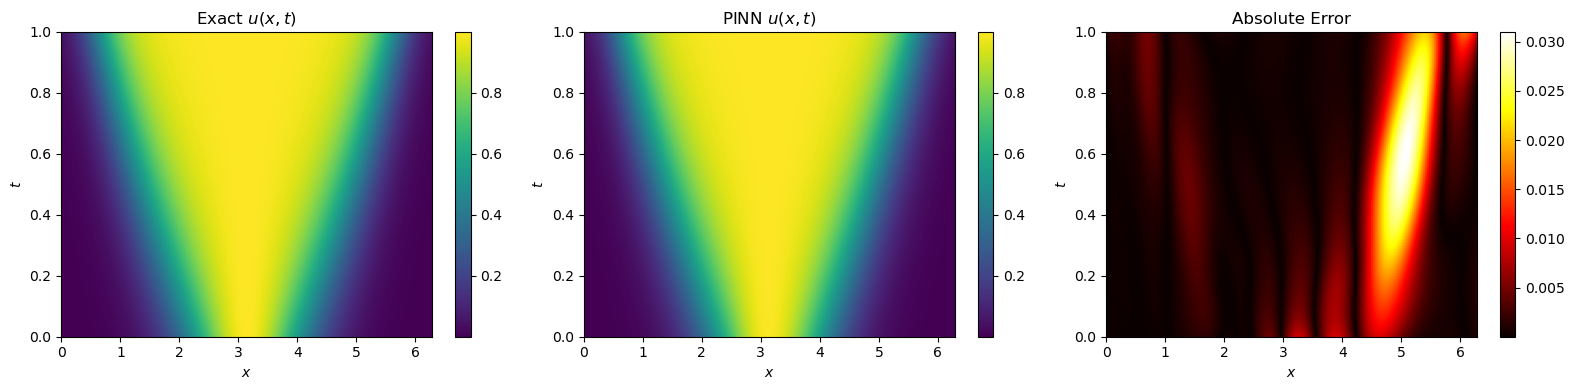

Relative L2 error: 1.1423e-02


In [26]:
Nx, Nt = 200, 100
x_grid = np.linspace(X_L, X_R, Nx)
t_grid = np.linspace(0.0, 1.0, Nt)
XX, TT = np.meshgrid(x_grid, t_grid)  # (Nt, Nx)

U_exact = exact(XX, TT)

model.eval()
xt_test = torch.tensor(
    np.stack([XX.ravel(), TT.ravel()], axis=1), dtype=torch.float32, device=device
)
with torch.no_grad():
    U_pred = model(xt_test).cpu().numpy().reshape(Nt, Nx)

U_err = np.abs(U_pred - U_exact)
vmin, vmax = U_exact.min(), U_exact.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kw = dict(origin="lower", extent=[X_L, X_R, 0, 1], aspect="auto")

im0 = axes[0].imshow(U_exact, cmap="viridis", vmin=vmin, vmax=vmax, **kw)
axes[0].set_title("Exact $u(x,t)$"); axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$t$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred,  cmap="viridis", vmin=vmin, vmax=vmax, **kw)
axes[1].set_title("PINN $u(x,t)$"); axes[1].set_xlabel("$x$"); axes[1].set_ylabel("$t$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(U_err, cmap="hot", **kw)
axes[2].set_title("Absolute Error"); axes[2].set_xlabel("$x$"); axes[2].set_ylabel("$t$")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

rel_l2 = np.linalg.norm(U_pred - U_exact) / (np.linalg.norm(U_exact) + 1e-10)
print(f"Relative L2 error: {rel_l2:.4e}")

## 7. Slice Comparison at Fixed Times

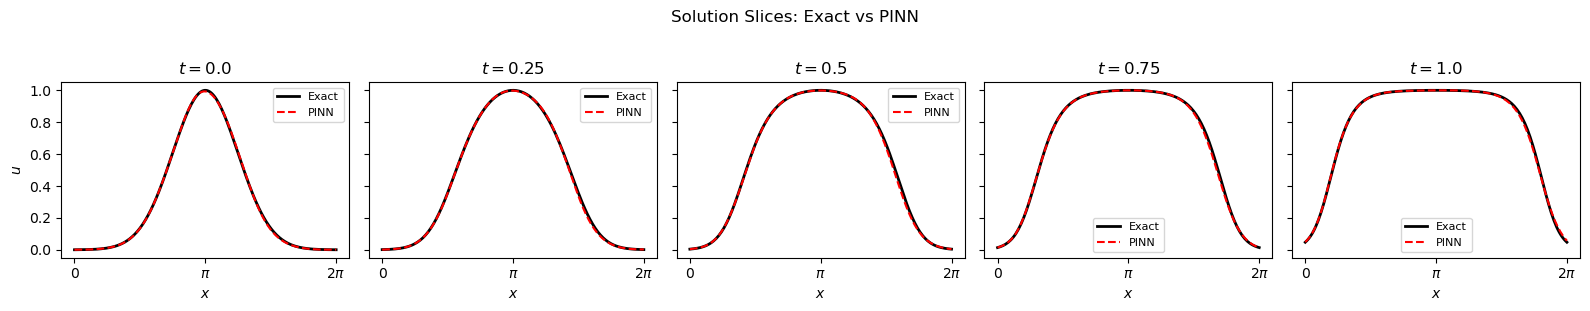

In [27]:
t_slices = [0.0, 0.25, 0.5, 0.75, 1.0]
x_plot = np.linspace(X_L, X_R, Nx)

fig, axes = plt.subplots(1, len(t_slices), figsize=(16, 3), sharey=True)
for ax, t_val in zip(axes, t_slices):
    t_idx = int(round(t_val * (Nt - 1)))
    ax.plot(x_plot, U_exact[t_idx], "k-",  lw=2,   label="Exact")
    ax.plot(x_plot, U_pred[t_idx],  "r--", lw=1.5, label="PINN")
    ax.set_title(f"$t = {t_val}$")
    ax.set_xlabel("$x$")
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels(["0", "$\\pi$", "$2\\pi$"])
    ax.legend(fontsize=8)

axes[0].set_ylabel("$u$")
plt.suptitle("Solution Slices: Exact vs PINN", y=1.02)
plt.tight_layout()
plt.show()